In [111]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy.stats as sts    # for plotting Q-Q plot

In [112]:
pd.read_csv('train.csv')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [113]:
df=pd.read_csv('train.csv',usecols=['Survived','Age','Fare'])

In [114]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [115]:
df.tail()

,Survived,Age,Fare
886,0,27.0,13.00
887,1,19.0,30.00
888,0,NaN,23.45
889,1,26.0,30.00
890,0,32.0,7.75


In [116]:
df.shape

(891, 3)

# We are going see the accuracy without transformation and compare it with accuracy after transformation 

# Checking accuracy without transformation

In [117]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [118]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [119]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [120]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [121]:
x = df[['Age', 'Fare']]
y = df['Survived']

In [122]:
x.head()

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500


In [123]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [124]:
from sklearn.model_selection import train_test_split

In [125]:
X_train, X_test, Y_train, Y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [126]:
# Plotting  Age Distribution ie probability distribution function pdf 

Text(0.5, 1.0, 'Age Plot')

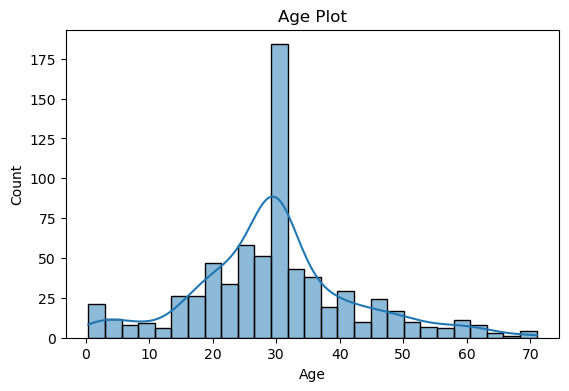

In [127]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(X_train['Age'], kde=True)
plt.title('Age Plot')


In [128]:
# Plotting Q-Q PLOT

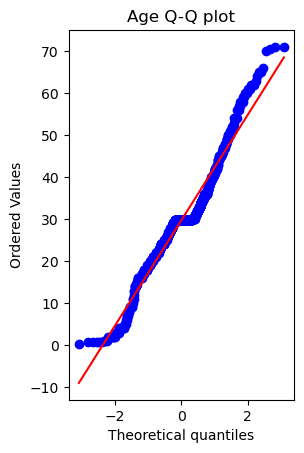

In [129]:
plt.subplot(122)
sts.probplot(X_train['Age'],dist="norm",plot=plt)
plt.title('Age Q-Q plot')
plt.show()

In [130]:
# Now plotting pdf for fare 

Text(0.5, 1.0, 'Fare pdf')

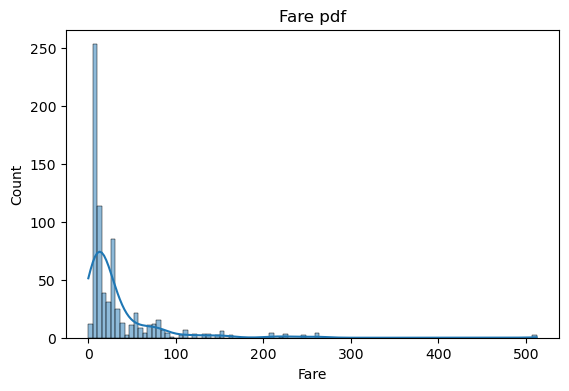

In [131]:
plt.figure(figsize=(14,4))
plt.subplot(122)
sns.histplot(X_train['Fare'], kde=True)
plt.title('Fare pdf')

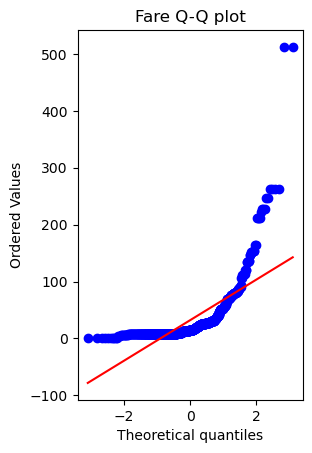

In [132]:
plt.subplot(122)
sts.probplot(X_train['Fare'],dist="norm",plot=plt)
plt.title('Fare Q-Q plot')
plt.show()

In [133]:
# Now lets check for accuracy 

In [134]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [135]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

In [136]:
clf.fit(X_train,Y_train)


LogisticRegression()

In [137]:
clf2.fit(X_train,Y_train)

DecisionTreeClassifier()

In [138]:
y_pred=clf.predict(X_test)
y_pred1=clf2.predict(X_test)

In [139]:
from sklearn.metrics import accuracy_score
print("Accuracy OF LR:",accuracy_score(Y_test,y_pred))
print("Accuracy OF DT:",accuracy_score(Y_test,y_pred1))

Accuracy OF LR: 0.6145251396648045
Accuracy OF DT: 0.5810055865921788


# Now we are going to use function transformer and then check for accuracy score and compare it  

In [140]:
from sklearn.preprocessing import FunctionTransformer

In [141]:
#1st call function transformer class , we will use log transform because its right skewed
trf=FunctionTransformer(func=np.log1p)

In [157]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [158]:

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [159]:
clf.fit(X_train_transformed, Y_train)


LogisticRegression()

In [160]:
clf2.fit(X_train_transformed, Y_train)


DecisionTreeClassifier()

In [161]:
y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)


In [162]:
print("Accuracy OF LR:", accuracy_score(Y_test, y_pred))
print("Accuracy OF DT:", accuracy_score(Y_test, y_pred1))

Accuracy OF LR: 0.6480446927374302
Accuracy OF DT: 0.5977653631284916


In [163]:
# Now we will plot pdf after transformation 

Text(0.5, 1.0, 'Q-Q PLOT OF AGE AFTER TRANSFORMTAION ')

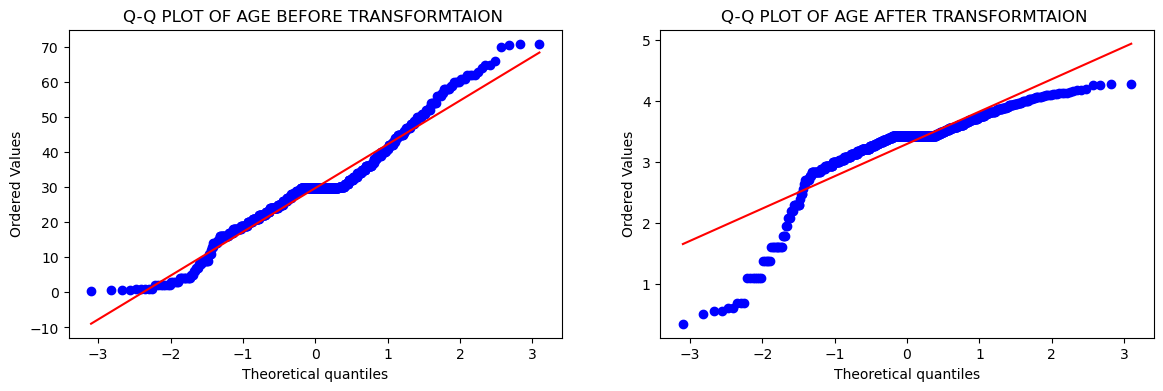

In [175]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sts.probplot(X_train['Age'],dist="norm",plot=plt)
plt.title("Q-Q PLOT OF AGE BEFORE TRANSFORMTAION ")
plt.subplot(122)
sts.probplot(X_train_transformed['Age'],dist="norm",plot=plt)
plt.title("Q-Q PLOT OF AGE AFTER TRANSFORMTAION ")

Text(0.5, 1.0, 'Q-Q PLOT OF FARE AFTER TRANSFORMTAION ')

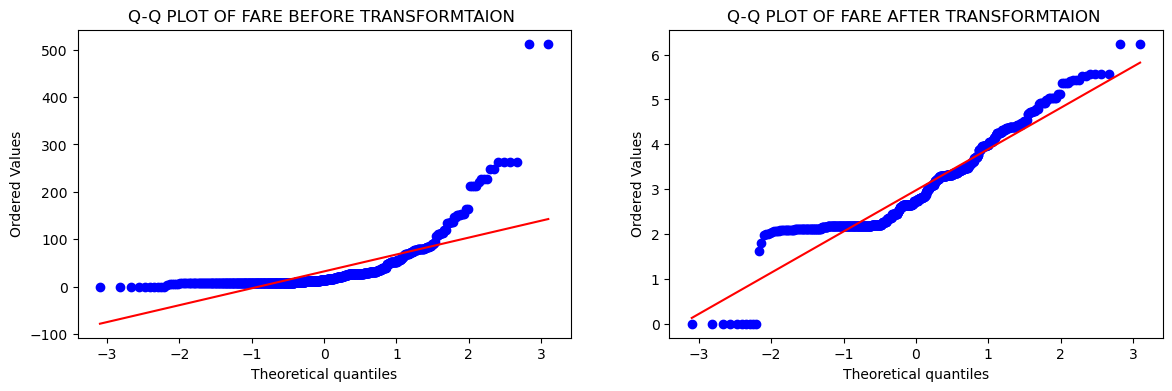

In [176]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sts.probplot(X_train['Fare'],dist="norm",plot=plt)
plt.title("Q-Q PLOT OF FARE BEFORE TRANSFORMTAION ")
plt.subplot(122)
sts.probplot(X_train_transformed['Fare'],dist="norm",plot=plt)
plt.title("Q-Q PLOT OF FARE AFTER TRANSFORMTAION ")

In [177]:
from sklearn.model_selection import cross_val_score

In [1]:
X_transformed=trf.fit_transform(x)
clf=LogisticRegression()
clf2=DecisionTreeClassifier()
print("LR:",np.mean(cross_val_score(clf,X_transformed,y,scoring="accuracy",cv=10)))
print("DR:",np.mean(cross_val_score(clf2,X_transformed,y,scoring="accuracy",cv=10)))

NameError: name 'trf' is not defined